# Numerical Integration in the McCall Search Model

*A worked example for evaluating expectations in dynamic models.*

Solving dynamic models almost always reduces to computing expectations:
$$
\mathbb{E}[g(W)] \;=\; \int g(w)\, f(w)\, dw,
$$
where $W$ is a random variable describing future shocks, $f$ is its density, and $g$ is some payoff or value function. In the **curse of expectation** view of dynamic models, this integral has to be computed *every iteration* of a Bellman operator, often *every grid point*, in *many dimensions*. The choice of quadrature is therefore not a minor implementation detail — it determines whether the model is tractable at all.

This notebook walks through several integration methods featured in the [QuantEcon](https://python.quantecon.org) lectures, applied to a single, classical example: the **McCall (1970) job-search model**. We pick the wage distribution to be **exponential**, because:

1. The reservation-wage equation admits an essentially closed form, giving us a clean benchmark.
2. The natural quadrature rule (Gauss–Laguerre) is *built for* $\int_0^\infty g(x)\,e^{-x}\,dx$, letting us see what the "right tool for the job" buys us.
3. The integrand $\max(w, w^*)$ has a **kink** at the reservation wage — a small but generic feature of dynamic programs (max operators, exercise boundaries, occasionally-binding constraints) that *breaks* spectral convergence. We will see exactly how, and exactly how to fix it.

### Roadmap

1. The McCall model and the reservation-wage equation.
2. Exponential wages: deriving the closed-form benchmark.
3. Five integration methods: Monte Carlo, trapezoidal, Simpson, Gauss–Legendre on a truncated domain, and Gauss–Laguerre.
4. Convergence comparison against the analytical benchmark.
5. The kink, and how to recover spectral convergence by splitting the integral.
6. Plugging each rule into a fixed-point iteration for $w^*$.

## 1. The McCall search model

An infinitely-lived unemployed worker faces, each period $t = 0, 1, 2, \dots$, the following decision. At the start of the period she draws a wage offer $W_t \sim F$, i.i.d. across periods. She must then:

- **Accept** the offer and work forever at wage $W_t$. The present value is $W_t/(1-\beta)$.
- **Reject** it, receive unemployment compensation $c$, and draw again next period.

Let $V_u$ denote the value of being unemployed at the start of a period (before observing the offer). The Bellman equation is
$$
V_u \;=\; \mathbb{E}\!\left[\max\!\left\{\frac{W}{1-\beta},\;\; c + \beta V_u\right\}\right].
$$
A **reservation wage** $w^\star$ is the wage at which the worker is exactly indifferent:
$$
\frac{w^\star}{1-\beta} \;=\; c + \beta V_u
\qquad\Longleftrightarrow\qquad
V_u \;=\; \frac{w^\star}{1-\beta}.
$$

Substituting and simplifying yields the **reservation-wage equation**:
$$
\boxed{\;\; w^\star \;=\; c \;+\; \frac{\beta}{1-\beta}\,\mathbb{E}\!\bigl[(W - w^\star)_+\bigr]\;\;}
\qquad\text{where}\quad (x)_+ = \max\{x, 0\}.
$$

The right-hand side is the flow value of waiting one more period: unemployment compensation $c$ plus the discounted **option value** of holding out for a better offer. The whole numerical content of the model sits inside the expectation $\mathbb{E}[(W - w^\star)_+]$.

## 2. Exponential wages and the closed-form benchmark

Suppose $W \sim \mathrm{Exp}(\lambda)$, i.e. density $f(w) = \lambda e^{-\lambda w}$ on $[0,\infty)$, mean $1/\lambda$. Then
$$
\mathbb{E}\!\bigl[(W - w^\star)_+\bigr]
\;=\; \int_{w^\star}^\infty (w - w^\star)\,\lambda e^{-\lambda w}\, dw
\;=\; e^{-\lambda w^\star} \int_0^\infty u\,\lambda e^{-\lambda u}\,du
\;=\; \frac{e^{-\lambda w^\star}}{\lambda},
$$
using the memorylessness substitution $u = w - w^\star$. The reservation-wage equation collapses to a one-dimensional nonlinear equation:
$$
\boxed{\;\; w^\star \;=\; c \;+\; \frac{\beta}{(1-\beta)\,\lambda}\, e^{-\lambda w^\star}.\;\;}
$$
This is the *gold-standard* answer we will compare every numerical method against. We will also use the related closed form
$$
\mathbb{E}\bigl[\max(W, w^\star)\bigr] \;=\; w^\star + \mathbb{E}[(W - w^\star)_+] \;=\; w^\star + \frac{e^{-\lambda w^\star}}{\lambda}
$$
as the test expectation in the convergence study below.

## 3. Setup and benchmark

We fix a single parameterisation throughout. Mean wage is normalised to $1/\lambda = 1$, the discount factor is $\beta = 0.96$, and unemployment compensation is $c = 0.6$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import roots_laguerre, roots_legendre

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

# ---- Model parameters ----
beta = 0.96   # discount factor
c    = 0.6    # unemployment compensation
lam  = 1.0    # exponential rate; E[W] = 1/lam

# ---- Closed-form reservation wage by 1-D root finding ----
def res_eq(w):
    return w - c - (beta / ((1 - beta) * lam)) * np.exp(-lam * w)

w_star_exact = brentq(res_eq, 1e-6, 50.0, xtol=1e-12)

# ---- Benchmark expectation E[max(W, w*)] ----
E_exact = w_star_exact + np.exp(-lam * w_star_exact) / lam

print(f"Reservation wage  w*       = {w_star_exact:.10f}")
print(f"Benchmark E[max(W, w*)]    = {E_exact:.10f}")

Reservation wage  w*       = 2.5237680444
Benchmark E[max(W, w*)]    = 2.6039250463


The worker holds out for offers about **2.5 times** the mean wage. The high reservation wage reflects the high discount factor: each extra period of search is cheap.

Let's visualise the reservation-wage equation, which is just a fixed point of $w \mapsto c + \tfrac{\beta}{(1-\beta)\lambda} e^{-\lambda w}$.

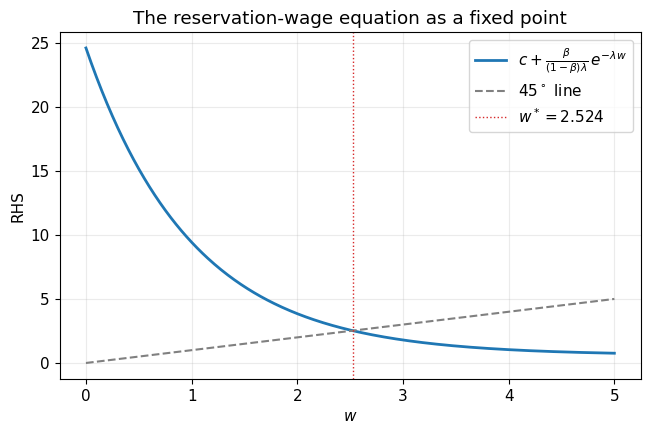

In [2]:
ws = np.linspace(0.0, 5.0, 400)
rhs = c + (beta / ((1 - beta) * lam)) * np.exp(-lam * ws)

fig, ax = plt.subplots()
ax.plot(ws, rhs, lw=2, label=r"$c + \frac{\beta}{(1-\beta)\lambda}\,e^{-\lambda w}$")
ax.plot(ws, ws, lw=1.5, ls="--", color="gray", label="$45^\\circ$ line")
ax.axvline(w_star_exact, lw=1, color="C3", ls=":", label=f"$w^* = {w_star_exact:.3f}$")
ax.set_xlabel("$w$")
ax.set_ylabel("RHS")
ax.set_title("The reservation-wage equation as a fixed point")
ax.legend(loc="upper right")
plt.show()

## 4. Five integration methods

Each method below computes an estimate of $\mathbb{E}[g(W)]$ for $W \sim \mathrm{Exp}(\lambda)$, where we will use $g(w) = \max(w, w^\star)$ as our test integrand. The methods differ in how they discretise the integral and in what they assume about the integrand.

### 4.1 Monte Carlo

The classic. Draw $W_1, \dots, W_N \stackrel{\text{iid}}{\sim} \mathrm{Exp}(\lambda)$ and approximate
$$
\mathbb{E}[g(W)] \;\approx\; \frac{1}{N}\sum_{i=1}^N g(W_i).
$$
The error decays as $O(N^{-1/2})$ regardless of dimension or smoothness of $g$. That dimension-independence is why Monte Carlo dominates in high-dimensional problems; the *cost* is its slow rate in low dimensions.

In [3]:
def E_mc(g, N, lam=lam, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    w = rng.exponential(1 / lam, size=N)
    return float(np.mean(g(w)))

### 4.2 Trapezoidal rule (Newton–Cotes, order 2)

Approximate the density $f$ and integrand $g$ on a *truncated* domain $[0, W_{\max}]$ with $N$ equally-spaced nodes, then apply the trapezoidal rule. The error has two pieces:

- **Truncation error**: $\int_{W_{\max}}^\infty g(w) f(w)\,dw$, which decays exponentially in $W_{\max}$ for the exponential density.
- **Discretisation error**: $O(h^2)$ where $h = W_{\max}/N$, *provided $g$ is $C^2$*.

For our integrand $g(w) = \max(w, w^\star)$, which is only Lipschitz at $w^\star$, the $O(h^2)$ rate degrades.

In [4]:
from scipy.integrate import simpson, trapezoid

def E_trap(g, N, lam=lam, W_max=20.0):
    w = np.linspace(0.0, W_max, N)
    integrand = g(w) * lam * np.exp(-lam * w)
    return float(trapezoid(integrand, w))

### 4.3 Simpson's rule (Newton–Cotes, order 4)

Same nodes as trapezoidal, but fits a quadratic through each consecutive triple of points. Error $O(h^4)$ on $C^4$ integrands. Higher order doesn't help against a kink: at best you get the same rate as trapezoidal in the neighborhood of $w^\star$.

In [5]:
def E_simpson(g, N, lam=lam, W_max=20.0):
    # Simpson requires odd number of points
    if N % 2 == 0:
        N += 1
    w = np.linspace(0.0, W_max, N)
    integrand = g(w) * lam * np.exp(-lam * w)
    return float(simpson(integrand, x=w))

### 4.4 Gauss–Legendre on a truncated domain

Gauss–Legendre quadrature picks $N$ nodes and weights that integrate polynomials up to degree $2N-1$ *exactly* on $[-1, 1]$. We rescale to $[0, W_{\max}]$ and multiply by the density. For *smooth* integrands on a bounded interval, the convergence is **spectral** (faster than any polynomial in $N$). Again, this rate is destroyed by the kink.

In [6]:
def E_gauss_legendre(g, N, lam=lam, W_max=20.0):
    x, wts = roots_legendre(N)            # nodes in [-1, 1]
    w = 0.5 * (x + 1.0) * W_max           # map to [0, W_max]
    jac = 0.5 * W_max
    integrand = g(w) * lam * np.exp(-lam * w)
    return float(jac * np.sum(wts * integrand))

### 4.5 Gauss–Laguerre

The natural choice when the density itself is of the form $e^{-x}$: Gauss–Laguerre nodes and weights satisfy
$$
\int_0^\infty h(x)\,e^{-x}\,dx \;\approx\; \sum_{i=1}^N w_i\, h(x_i),
$$
exactly when $h$ is a polynomial of degree $\le 2N-1$. With the substitution $u = \lambda w$,
$$
\mathbb{E}[g(W)] \;=\; \int_0^\infty g(w)\,\lambda e^{-\lambda w}\,dw
\;=\; \int_0^\infty g\!\left(\tfrac{u}{\lambda}\right)\, e^{-u}\,du
\;\approx\; \sum_{i=1}^N w_i\, g\!\left(\tfrac{x_i}{\lambda}\right).
$$
No truncation, no density-weighting by hand — the rule absorbs the exponential weight into the nodes. This is what we mean by *matching the quadrature to the structure*.

In [7]:
def E_gauss_laguerre(g, N, lam=lam):
    x, wts = roots_laguerre(N)
    return float(np.sum(wts * g(x / lam)))

### 4.6 Quick sanity check

Each method should land near the benchmark $\mathbb{E}[\max(W, w^\star)] = w^\star + e^{-\lambda w^\star}/\lambda$.

In [8]:
g = lambda w: np.maximum(w - w_star_exact, 0.0)
E_option_exact = np.exp(-lam * w_star_exact) / lam

print(f"Exact                  : {E_option_exact:.10f}")
print(f"Monte Carlo (N=1e5)    : {E_mc(g, 100_000):.10f}")
print(f"Trapezoidal (N=200)    : {E_trap(g, 200):.10f}")
print(f"Simpson (N=201)        : {E_simpson(g, 201):.10f}")
print(f"Gauss-Legendre (N=64)  : {E_gauss_legendre(g, 64):.10f}")
print(f"Gauss-Laguerre (N=64)  : {E_gauss_laguerre(g, 64):.10f}")

Exact                  : 0.0801570019
Monte Carlo (N=1e5)    : 0.0804551276
Trapezoidal (N=200)    : 0.0801285762
Simpson (N=201)        : 0.0801241738
Gauss-Legendre (N=64)  : 0.0799951959
Gauss-Laguerre (N=64)  : 0.0809852285


## 5. Convergence comparison

For each method, we sweep the number of nodes $N$ and record the absolute error against the exact benchmark. We use the **option-value** integrand $g(w) = (w - w^\star)_+$, since this is precisely what appears in the reservation-wage equation. Its exact expectation is $e^{-\lambda w^\star}/\lambda$.

This is the single most informative plot in numerical-methods pedagogy: it shows you not just *which* method is best, but *at what rate* each method buys you accuracy per evaluation.

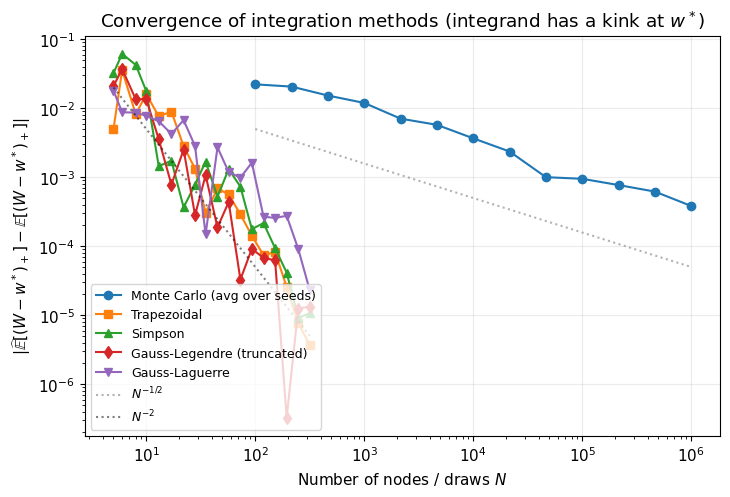

In [9]:
g = lambda w: np.maximum(w - w_star_exact, 0.0)
benchmark = np.exp(-lam * w_star_exact) / lam

# Node counts to sweep
Ns_quad = np.unique(np.round(np.logspace(0.7, 2.5, 18)).astype(int))   # 5 .. ~316
Ns_mc   = np.unique(np.round(np.logspace(2, 6, 13)).astype(int))       # 100 .. 1e6

# For Monte Carlo, average over several seeds to get a stable error curve
def E_mc_avg(g, N, n_seeds=20):
    estimates = []
    for s in range(n_seeds):
        rng = np.random.default_rng(s)
        estimates.append(E_mc(g, N, rng=rng))
    return np.mean(np.abs(np.array(estimates) - benchmark))

err_trap = np.array([abs(E_trap(g, N) - benchmark)            for N in Ns_quad])
err_simp = np.array([abs(E_simpson(g, N) - benchmark)         for N in Ns_quad])
err_glg  = np.array([abs(E_gauss_legendre(g, N) - benchmark)  for N in Ns_quad])
err_lag  = np.array([abs(E_gauss_laguerre(g, N) - benchmark)  for N in Ns_quad])
err_mc   = np.array([E_mc_avg(g, N)                            for N in Ns_mc])

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.loglog(Ns_mc,   err_mc,   "o-",  label="Monte Carlo (avg over seeds)")
ax.loglog(Ns_quad, err_trap, "s-",  label="Trapezoidal")
ax.loglog(Ns_quad, err_simp, "^-",  label="Simpson")
ax.loglog(Ns_quad, err_glg,  "d-",  label="Gauss-Legendre (truncated)")
ax.loglog(Ns_quad, err_lag,  "v-",  label="Gauss-Laguerre")

# Reference slopes
ax.loglog(Ns_mc,   0.05/np.sqrt(Ns_mc),  ":", color="gray", alpha=0.6, label=r"$N^{-1/2}$")
ax.loglog(Ns_quad, 0.5/Ns_quad**2,       ":", color="black", alpha=0.5, label=r"$N^{-2}$")

ax.set_xlabel("Number of nodes / draws $N$")
ax.set_ylabel(r"$|\widehat{\mathbb{E}}[(W - w^*)_+] - \mathbb{E}[(W - w^*)_+]|$")
ax.set_title("Convergence of integration methods (integrand has a kink at $w^*$)")
ax.legend(loc="lower left", fontsize=9)
plt.show()

### Reading the plot

A few things to notice — these are the *core lessons* of the exercise.

1. **Monte Carlo** sits on a clean $N^{-1/2}$ line. No surprises.

2. **All the smooth quadrature rules** (trapezoidal, Simpson, Gauss–Legendre, Gauss–Laguerre) cluster around the $N^{-2}$ slope. This is *not* their advertised rate. Simpson should be $N^{-4}$; the two Gauss rules should be spectral. They aren't, because the integrand $(w - w^\star)_+$ has a Lipschitz kink at $w^\star$, and **a single $C^0$ point in the integrand drags every smooth quadrature rule down to a polynomial rate.**

3. **Gauss–Laguerre is no better than trapezoidal** here. This is the most counter-intuitive lesson: the "right tool for the job" is not the one that matches the density — it is the one that matches the *combined regularity* of the integrand and the density.

4. Even so, the smooth rules **beat Monte Carlo by orders of magnitude** for a given $N$. To get Monte Carlo down to the error a 50-node Gauss rule delivers, you need on the order of $10^6$ draws.

This is the kink phenomenon. It is generic in dynamic programming: max operators, exercise boundaries, occasionally-binding constraints, and discrete-choice cutoffs all produce kinks.

## 6. Restoring spectral convergence: split at the kink

The fix is mechanical: the *only* non-smooth point of the integrand is $w^\star$. So split the domain there. For the option-value integrand,
$$
\mathbb{E}[(W - w^\star)_+] \;=\; \underbrace{\int_0^{w^\star}\!0 \cdot \lambda e^{-\lambda w}\,dw}_{=\,0} \;+\; \int_{w^\star}^\infty (w - w^\star)\,\lambda e^{-\lambda w}\,dw.
$$
The change of variables $u = \lambda(w - w^\star)$ turns the right piece into
$$
\int_{w^\star}^\infty (w - w^\star)\,\lambda e^{-\lambda w}\,dw \;=\; \frac{e^{-\lambda w^\star}}{\lambda}\int_0^\infty u\, e^{-u}\,du,
$$
and the integrand $u$ is a *polynomial of degree 1*. Gauss–Laguerre with $N \ge 1$ nodes integrates polynomials of degree $\le 2N-1$ exactly, so $N=1$ already gives the exact answer up to floating-point error.

More generally, for any integrand $g$ that vanishes on $[0, w^\star]$ (i.e. anything that is "off below the threshold"), the split rule is just Gauss–Laguerre after shifting the lower limit to $w^\star$.

In [10]:
def E_gauss_laguerre_split(g, N, w_bar, lam=lam):
    # Assumes g(w) = 0 for w <= w_bar. Applies Gauss-Laguerre on [w_bar, inf)
    # via the change of variables u = lam (w - w_bar).
    x, wts = roots_laguerre(N)
    w_nodes = w_bar + x / lam
    return float(np.exp(-lam * w_bar) * np.sum(wts * g(w_nodes)))

g = lambda w: np.maximum(w - w_star_exact, 0.0)
for N in [1, 2, 4, 8, 16]:
    est = E_gauss_laguerre_split(g, N, w_star_exact)
    print(f"  split Gauss-Laguerre  N={N:>2}  est = {est:.14f}   err = {abs(est-benchmark):.2e}")

  split Gauss-Laguerre  N= 1  est = 0.08015700185044   err = 0.00e+00
  split Gauss-Laguerre  N= 2  est = 0.08015700185044   err = 1.39e-17
  split Gauss-Laguerre  N= 4  est = 0.08015700185044   err = 5.55e-17
  split Gauss-Laguerre  N= 8  est = 0.08015700185044   err = 4.16e-17
  split Gauss-Laguerre  N=16  est = 0.08015700185044   err = 5.55e-17


At $N=1$ the split rule is already at machine precision. With the kink isolated, the integrand on each side is a polynomial in $u$ (in fact, *linear*), and Gauss–Laguerre with one node integrates linear polynomials exactly. This is the "matching" principle the textbooks promise: quadrature is exact for polynomials of the right degree, *provided the integrand is actually a polynomial of that degree on the domain you apply it to*.

In practice, you do not know where the kink is — it is the solution of the model. Two responses:

- **Adaptive splitting**: detect kinks by monitoring derivatives of the value/policy function on the grid, and split.
- **Just live with the $N^{-2}$ rate**, since it still dominates Monte Carlo in low dimensions.

Both are used in practice. In high dimensions, the kinks lie on lower-dimensional manifolds and explicit splitting becomes infeasible; this is one of the reasons modern methods (sparse grids, machine-learning-based function approximation) become attractive.

## 7. Plugging the rules into the McCall fixed point

Finally, we replace the closed-form expectation in the reservation-wage equation
$$
w^\star \;=\; c + \frac{\beta}{1-\beta}\,\mathbb{E}[(W - w^\star)_+]
$$
with each numerical rule, and solve the resulting equation by root-finding. This is the closest analog to how you would actually use these methods inside a value-function iteration.

In [11]:
def reservation_wage(integrate, **kw):
    # integrate(g, **kw) must return an approximation of E[g(W)].
    # g will be passed as a callable; kw is forwarded.
    def F(w):
        g = lambda x: np.maximum(x - w, 0.0)
        return w - c - (beta / (1 - beta)) * integrate(g, **kw)
    return brentq(F, 1e-6, 50.0, xtol=1e-10)


results = []
results.append(("Exact (closed form)",              w_star_exact))
results.append(("Monte Carlo (N=10^5)",             reservation_wage(E_mc, N=100_000)))
results.append(("Trapezoidal (N=200, W_max=20)",    reservation_wage(E_trap, N=200)))
results.append(("Simpson (N=201, W_max=20)",        reservation_wage(E_simpson, N=201)))
results.append(("Gauss-Legendre (N=64, W_max=20)",  reservation_wage(E_gauss_legendre, N=64)))
results.append(("Gauss-Laguerre (N=64)",            reservation_wage(E_gauss_laguerre, N=64)))
results.append(("Gauss-Laguerre split (N=8)",
                brentq(lambda w: w - c - (beta/(1-beta)) *
                       E_gauss_laguerre_split(lambda x: np.maximum(x - w, 0.0), 8, w),
                       1e-6, 50.0, xtol=1e-10)))

print(f"{'Method':<35s} {'w*':>14s} {'|err|':>12s}")
print("-" * 63)
for name, w in results:
    print(f"{name:<35s} {w:>14.10f} {abs(w - w_star_exact):>12.2e}")

Method                                          w*        |err|
---------------------------------------------------------------
Exact (closed form)                   2.5237680444     0.00e+00
Monte Carlo (N=10^5)                  2.5262073809     2.44e-03
Trapezoidal (N=200, W_max=20)         2.5235286138     2.39e-04
Simpson (N=201, W_max=20)             2.5234908185     2.77e-04
Gauss-Legendre (N=64, W_max=20)       2.5223381973     1.43e-03
Gauss-Laguerre (N=64)                 2.5310362241     7.27e-03
Gauss-Laguerre split (N=8)            2.5237680444     4.80e-12


A few things worth noting in the table:

- The **split Gauss–Laguerre** rule with only **8 nodes** hits machine precision.
- The **un-split Gauss–Laguerre** with 64 nodes is no better than the trapezoidal rule with 200 — both bottlenecked by the kink.
- **Monte Carlo with $10^5$ draws** is, as the convergence plot predicted, the worst of the deterministic methods at this budget.

The headline message is the same one Judd and the QuantEcon lectures stress, but seen here with full numerical clarity: *choose your quadrature to match the structure of the integrand, not just the structure of the density.*

### Connection to the chapter on the curse of expectation

In a typical Bellman iteration, the integrand we have just spent a notebook discussing — $\max(w, w^\star)$ — is the continuation value $\max\{V_e(w), V_u\}$ that appears under the expectation in every Bellman equation with a discrete-choice or stopping component. The kink we just diagnosed is the **discrete-choice cutoff**, and the broken convergence rates we just saw are the reason that off-the-shelf Gaussian quadrature works disappointingly in models with default thresholds, exercise boundaries, irreversible investment, or any other "max" structure. The "curse of expectation" in such models is not just about dimension; it is about the *interaction of dimension and non-smoothness*. That is the bridge into the rest of the chapter.